In [4]:
import pandas as pd
import numpy as np
import sys
import importlib

# 1. 重新加载修改后的核心引擎 (importlib.reload 确保读取到最新的修改)
sys.path.append('../')
import src.analyzer
importlib.reload(src.analyzer)
from src.analyzer import OlistBIEngine

# 2. 读取底层数据
df_orders_clean = pd.read_parquet("../data/processed/olist_orders_clean.parquet")
df_payments_clean = pd.read_parquet("../data/processed/olist_payments_clean.parquet")
df_customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
df_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
df_products = pd.read_csv("../data/raw/olist_products_dataset.csv")

# 3. 生成带 payment_value 的新版 ABT 大表
print("⚙️ 引擎重载完毕，正在构建新版全维分析大表...")
engine = OlistBIEngine(df_orders_clean, df_payments_clean, df_customers, df_items, df_products)
df_abt = engine.build_analytical_base_table()

# 4. RFM 安全计算逻辑
print("🚀 正在提取买家资产，构筑 RFM 基础矩阵...")
snapshot_date = df_abt['purchase_dt'].max() + pd.Timedelta(days=1)

# R 和 F 的计算
df_rf = df_abt.groupby('customer_unique_id').agg({
    'purchase_dt': lambda x: (snapshot_date - x.max()).days, # R
    'order_id': 'nunique'                                    # F
}).reset_index()

# M 的安全计算：剔除商品明细带来的订单行重复，按订单级唯一去重后再加总
df_m = df_abt[['customer_unique_id', 'order_id', 'payment_value']].drop_duplicates()
df_m = df_m.groupby('customer_unique_id')['payment_value'].sum().reset_index()

# 拼装最终 RFM 矩阵
df_rfm = pd.merge(df_rf, df_m, on='customer_unique_id')
df_rfm.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

print("\n=== RFM 核心资产体检报告 ===")
print(df_rfm[['Recency', 'Frequency', 'Monetary']].describe())

⚙️ 引擎重载完毕，正在构建新版全维分析大表...
🚀 正在提取买家资产，构筑 RFM 基础矩阵...

=== RFM 核心资产体检报告 ===
            Recency     Frequency      Monetary
count  93828.000000  93828.000000  93828.000000
mean     245.294965      1.033817    166.270706
std      152.822324      0.210657    228.953412
min        1.000000      1.000000      9.590000
25%      122.000000      1.000000     63.100000
50%      227.000000      1.000000    107.985000
75%      354.000000      1.000000    183.430000
max      729.000000     16.000000  13664.080000


In [5]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ==================== 1. 算法预处理：抗偏态与标准化 ====================
print("⚙️ 正在对 RFM 资产进行 Log 对数压缩与特征标准化...")
# 使用 log1p (即 log(x+1)) 防止取对数时遇到 0 的数学错误
rfm_log = np.log1p(df_rfm[['Recency', 'Frequency', 'Monetary']])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# ==================== 2. K-Means 无监督聚类 ====================
print("🧠 正在启动 K-Means 无监督机器学习聚类...")
# 我们设定 k=4，将用户划分为 4 个具有显著差异的群体
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# ==================== 3. 商业打标与画像描绘 ====================
print("\n=== K-Means 自动分群画像 (聚类中心) ===")
# 统计每个簇的平均 R, F, M 以及包含的人数
cluster_summary = df_rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'customer_unique_id': 'count'
}).round(2)

# 计算每个群体的人数占比
cluster_summary.rename(columns={'customer_unique_id': 'User_Count'}, inplace=True)
cluster_summary['User_Share_%'] = (cluster_summary['User_Count'] / cluster_summary['User_Count'].sum() * 100).round(2)

print(cluster_summary)

⚙️ 正在对 RFM 资产进行 Log 对数压缩与特征标准化...
🧠 正在启动 K-Means 无监督机器学习聚类...

=== K-Means 自动分群画像 (聚类中心) ===
         Recency  Frequency  Monetary  User_Count  User_Share_%
Cluster                                                        
0         282.07       1.00    298.61       32075         34.18
1         297.30       1.00     68.13       41932         44.69
2         228.04       2.11    310.54        2848          3.04
3          50.22       1.00    134.42       16973         18.09


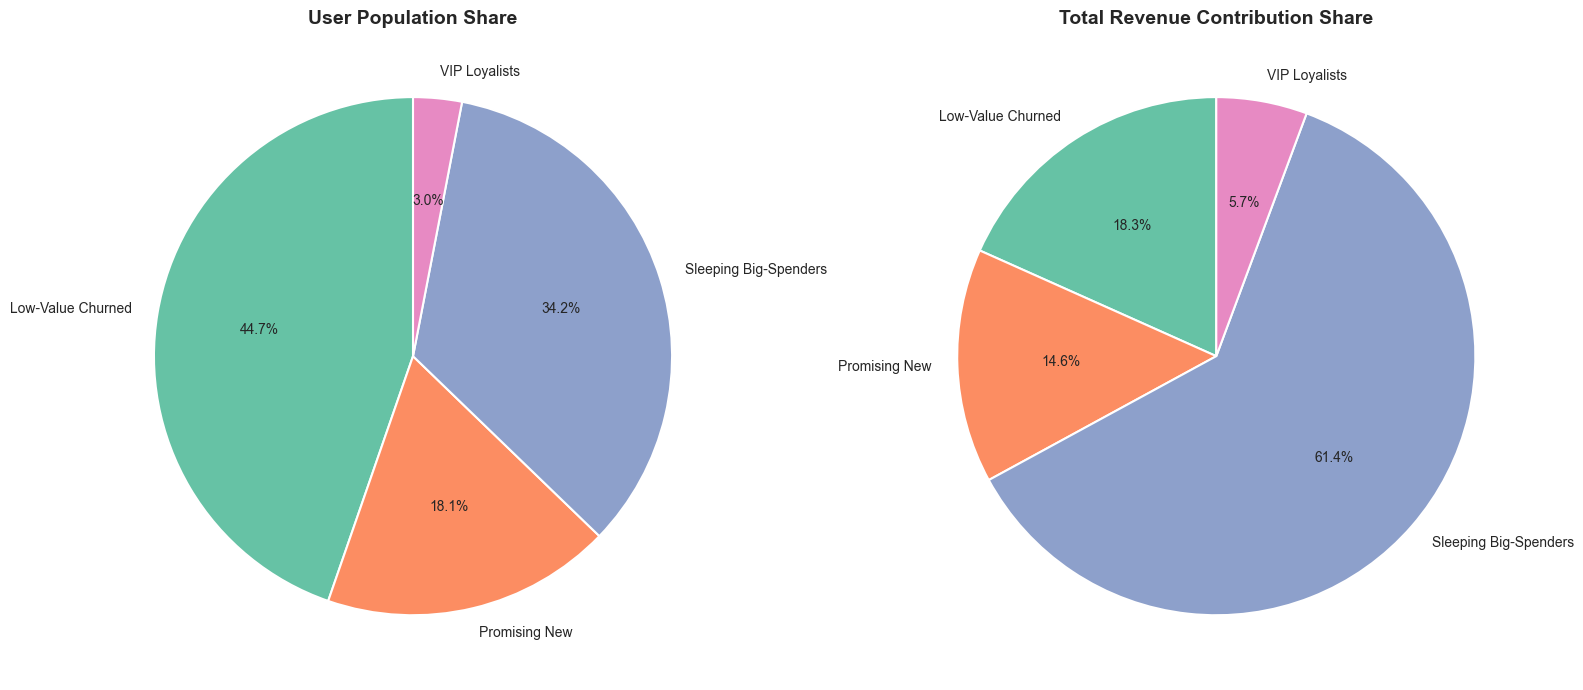

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 屏蔽烦人的系统级警告
warnings.filterwarnings('ignore')

# 1. 采用纯英文的商业标签映射，彻底绕过字体 Bug
cluster_names = {
    2: 'VIP Loyalists',          # 核心金主
    3: 'Promising New',          # 潜力新星
    0: 'Sleeping Big-Spenders',  # 沉睡大客
    1: 'Low-Value Churned'       # 长尾流失 (羊毛党)
}
df_rfm['Segment'] = df_rfm['Cluster'].map(cluster_names)

# 2. 统计各群体的【总人数】与【总贡献金额】
segment_summary = df_rfm.groupby('Segment').agg({
    'customer_unique_id': 'count',
    'Monetary': 'sum'
}).rename(columns={'customer_unique_id': 'Total_Users', 'Monetary': 'Total_Revenue'})

# 3. 可视化：人数占比 vs 营收占比 (直观展现商业二八定律)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = sns.color_palette("Set2")

# 左图：人数占比
axes[0].pie(segment_summary['Total_Users'], labels=segment_summary.index, autopct='%1.1f%%',
            startangle=90, colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title("User Population Share", fontsize=14, fontweight='bold')

# 右图：营收贡献占比
axes[1].pie(segment_summary['Total_Revenue'], labels=segment_summary.index, autopct='%1.1f%%',
            startangle=90, colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title("Total Revenue Contribution Share", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import sys
import importlib

# 1. 重载更新后的引擎
sys.path.append('../')
import src.analyzer
importlib.reload(src.analyzer)
from src.analyzer import OlistBIEngine

# 2. 传入底层数据（假设你之前已经读取了，这里为了保险再读一次核心表）
df_orders_clean = pd.read_parquet("../data/processed/olist_orders_clean.parquet")
df_payments_clean = pd.read_parquet("../data/processed/olist_payments_clean.parquet")
df_customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
df_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
df_products = pd.read_csv("../data/raw/olist_products_dataset.csv")

# 3. 实例化引擎 -> 激活主表 -> 一键执行 RFM 机器学习聚类！
engine = OlistBIEngine(df_orders_clean, df_payments_clean, df_customers, df_items, df_products)
engine.build_analytical_base_table()

print("🧠 正在调用引擎内置算法进行千万级用户聚类...")
df_rfm_final = engine.generate_rfm_segments()

# 4. 打印最终大捷报告
print("\n🎉 RFM 模块工程化彻底成功！最终产出的用户资产库：")
print(df_rfm_final.sample(5)) # 随机抽查 5 个用户的资产和标签

🧠 正在调用引擎内置算法进行千万级用户聚类...

🎉 RFM 模块工程化彻底成功！最终产出的用户资产库：
                     customer_unique_id  Recency  Frequency  Monetary  \
37009  64cc5b70a25c40aeb6f383cd595e6d4b      128          1    311.35   
41456  70ffa6734aa0f9882e8f6aec13de6b1e      465          1    366.14   
32148  57760bbba1b56ea6bbf29939e6c869ce      259          1    138.60   
46785  7f78ef49a3ec6ff5ca63eb05bf82fefc       42          1    584.33   
90524  f6e24a8ed9e6015242b1f988eabaef95       76          1    239.38   

       Cluster                Segment  
37009        0  Sleeping Big-Spenders  
41456        0  Sleeping Big-Spenders  
32148        0  Sleeping Big-Spenders  
46785        3          Promising New  
90524        3          Promising New  


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("⚙️ 正在清洗标签，构建防穿越的特征工程...")
# 1. 构造流失标签 (Churn): 距离上次购买超过 180 天定义为已流失 (1)，否则为安全/活跃 (0)
df_rfm['is_churn'] = (df_rfm['Recency'] > 180).astype(int)

# 2. 引入体验特征：到底是不是物流太慢、运费太贵导致了用户发誓不再来？
# 从大表中提取每个用户的平均物流耗时、平均运费、平均商品重量
df_experience = df_abt.groupby('customer_unique_id').agg({
    'days_total_fulfillment': 'mean',
    'freight_value': 'mean',
    'product_weight_g': 'mean'
}).reset_index()

# 将体验特征完美拼接到 RFM 矩阵上
df_model = pd.merge(df_rfm, df_experience, on='customer_unique_id')

# 3. 剥离特征 (X) 与标签 (y)
# ⚠️ 绝对禁忌：强行剔除 Recency、Cluster、Segment 等包含答案的泄漏特征
X = df_model[['Frequency', 'Monetary', 'days_total_fulfillment', 'freight_value', 'product_weight_g']]
y = df_model['is_churn']

# 划分训练集和测试集 (加入 stratify 保证正负样本比例均匀)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. 召唤大杀器：训练 XGBoost 分类器
print("🧠 正在训练 XGBoost 用户流失预测模型...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# 5. 模型评估与特征重要性解剖
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== 🏆 XGBoost 模型评估报告 ===")
print(f"ROC-AUC 得分: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\n核心分类报告:")
print(classification_report(y_test, y_pred))

# 提取特征重要性
importance = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n👉 导致用户流失的真实元凶 (特征权重):")
print(importance)

⚙️ 正在清洗标签，构建防穿越的特征工程...
🧠 正在训练 XGBoost 用户流失预测模型...

=== 🏆 XGBoost 模型评估报告 ===
ROC-AUC 得分: 0.8826

核心分类报告:
              precision    recall  f1-score   support

           0       0.81      0.65      0.72      7283
           1       0.80      0.90      0.85     11483

    accuracy                           0.81     18766
   macro avg       0.81      0.78      0.79     18766
weighted avg       0.81      0.81      0.80     18766


👉 导致用户流失的真实元凶 (特征权重):
freight_value             0.429105
days_total_fulfillment    0.239740
Monetary                  0.142079
product_weight_g          0.135656
Frequency                 0.053420
dtype: float32
